# Out of distribution 

Load data

In [1]:
import pandas as pd 

df = pd.read_csv("data/moljepa_results.csv")
baseline_df = pd.read_csv("data/baseline_results.csv")

print(df.shape)
print(baseline_df.shape)

(368, 14)
(528, 11)


In [2]:
from config import CV_DS_MAP

name_map = {
    "Chemprop": "Chemprop",
    "LGBM_desc": "LGBM",
    "RF_ECFP4": "RF",
    "Chemeleon": "Chemeleon",
    "TabICL_desc": "TabICL",
    "CLAMP": "CLAMP",
    "Mol-JEPA (best)": "Mol-JEPA",
}
datasets = df.dataset.unique().tolist()

# Filter baseline_df to only include the models that are in name_map
baseline_df = baseline_df[baseline_df["model"].isin(name_map.keys())]

### Out of distribution generalization

In [3]:
import numpy as np
from ast import literal_eval
from rdkit import Chem
from config import CV_DS_MAP
from tqdm import tqdm
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from config import CLUSTER_SPLITS
from sklearn.metrics import mean_absolute_error

SPLITS = ["split1", "split2", "split3"]

_fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def smiles_to_fp_matrix(smiles_iter, desc="Fingerprinting"):
    """SMILES -> (N_valid, N_BITS) uint8 bit matrix + list of valid SMILES."""
    mats, valid = [], []
    for s in list(smiles_iter):
        if not isinstance(s, str):
            continue
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        fp = _fpgen.GetFingerprint(m)
        arr = np.zeros((1024,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        mats.append(arr)
        valid.append(s)
    return np.asarray(mats, dtype=np.uint8), valid


def max_tanimoto_to_ref(query_fps, ref_fps, chunk=128):
    """Nearest-neighbour Tanimoto of each query to the reference set."""
    q = query_fps.astype(np.float32)
    q_pop = q.sum(axis=1)
    max_sim = np.zeros(q.shape[0], dtype=np.float32)
    n_chunks = (ref_fps.shape[0] + chunk - 1) // chunk
    for start in range(0, ref_fps.shape[0], chunk):
        r = ref_fps[start : start + chunk].astype(np.float32)
        r_pop = r.sum(axis=1)
        inter = q @ r.T
        union = q_pop[:, None] + r_pop[None, :] - inter
        sim = inter / np.maximum(union, 1e-9)
        max_sim = np.maximum(max_sim, sim.max(axis=1))
    return max_sim

dfs = []
clamp_dfs = []
y_true_mapping = {dataset: {} for dataset in datasets}


def process_row(row, split, model="Mol-JEPA"):
    row_data = row[split]
    # SMILES data lookup
    suppl = Chem.SDMolSupplier(CLUSTER_SPLITS[row["dataset"]])
    train_data = []
    test_data = []
    for mol in suppl:
        if mol.GetProp(split) == "test":
            test_data.append(Chem.MolToSmiles(mol))
        elif mol.GetProp(split) == "train":
            train_data.append(Chem.MolToSmiles(mol))
    
    # Compute tanimoto similarity between test and train data
    train_fps, train_valid = smiles_to_fp_matrix(train_data, desc="Train FPs")
    test_fps, test_valid = smiles_to_fp_matrix(test_data, desc="Test FPs")
    max_sim = max_tanimoto_to_ref(test_fps, train_fps, chunk=128) 

    row_dict = literal_eval(row_data)
    row_dict["split"] = split
    y_true = row_dict["y_true_test"]
    y_pred = row_dict["y_pred_test"]
    y_true_mapping[row["dataset"]][split] = y_true
    row_df_exploded = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, 
                                    "smiles": test_data, "max_sim": max_sim})
    row_df_exploded["model"] = model
    row_df_exploded["dataset"] = CV_DS_MAP[row["dataset"]]
    row_df_exploded["split"] = split
    return row_df_exploded

# For each dataset, find the best (variant, features) combo by average MAE across splits
non_clamp = df[df["variant"] != "clamp"]
best_combo = {}
for dataset in datasets:
    ds_rows = non_clamp[non_clamp["dataset"] == dataset]
    best_mae = float("inf")
    best_key = None
    for (variant, features), group in ds_rows.groupby(["variant", "features"]):
        maes = []
        for _, row in group.iterrows():
            for split in SPLITS:
                row_dict = literal_eval(row[split])
                y_true = row_dict["y_true_test"]
                y_pred = row_dict["y_pred_test"]
                maes.append(mean_absolute_error(y_true, y_pred))
        avg_mae = np.mean(maes)
        if avg_mae < best_mae:
            best_mae = avg_mae
            best_key = (variant, features)
    best_combo[dataset] = best_key
    print(f"{dataset}: best combo = {best_key} (MAE={best_mae:.4f})")

for i, row in tqdm(df.iterrows(), total=df.shape[0]):
    for split in SPLITS:
        if row["variant"] == "clamp":
            row_df_exploded = process_row(row, split, model="CLAMP")
            clamp_dfs.append(row_df_exploded)
        elif (row["variant"], row["features"]) == best_combo.get(row["dataset"]):
            row_df_exploded = process_row(row, split)
            dfs.append(row_df_exploded)

moljepa_preds = pd.concat(dfs, ignore_index=True)
clamp_preds = pd.concat(clamp_dfs, ignore_index=True)
moljepa_preds.head(5)

ASAP_ADMET_HLM: best combo = ('transformer', 'embeddings') (MAE=0.3936)
ASAP_ADMET_KSOL: best combo = ('transformer', 'cls') (MAE=0.4164)
ASAP_ADMET_LogD: best combo = ('transformer', 'cls') (MAE=0.6766)
ASAP_ADMET_MDR1: best combo = ('transformer', 'latent') (MAE=0.4179)
ASAP_ADMET_MLM: best combo = ('transformer', 'embeddings') (MAE=0.5284)
ASAP_POTENCY_MERS: best combo = ('tabicl', 'cls') (MAE=0.5924)
ASAP_POTENCY_SARS: best combo = ('transformer', 'embeddings') (MAE=0.6168)
BIOGEN_HLM_Clint: best combo = ('transformer', 'latent') (MAE=0.3253)
BIOGEN_MDR1: best combo = ('transformer', 'concat') (MAE=0.2675)
BIOGEN_PPBhuman: best combo = ('transformer', 'latent') (MAE=0.3281)
BIOGEN_PPBrat: best combo = ('transformer', 'latent') (MAE=0.4271)
BIOGEN_RLM_CLint: best combo = ('transformer', 'concat') (MAE=0.3725)
BIOGEN_Solubility: best combo = ('transformer', 'embeddings') (MAE=0.3044)
OPENADMET_Caco2_efflux: best combo = ('finetuned', 'finetuned') (MAE=0.2536)
OPENADMET_Caco2_pappA: b

100%|██████████| 368/368 [01:26<00:00,  4.27it/s]


,y_true,y_pred,smiles,max_sim,model,dataset,split
0,2.025306,1.868426,CNC(=O)c1cc(Cl)ccc1NS(=O)(=O)c1ccc(Oc2ccccc2Cl...,0.234375,Mol-JEPA,asap_admet_HLM,split1
1,1.348305,1.762185,Cc1cc(OCc2ccccc2)ccc1NS(=O)(=O)c1ccc(Cl)cc1C(=...,0.305882,Mol-JEPA,asap_admet_HLM,split1
2,2.075547,1.672887,CCOc1cccc(-c2ccc(S(=O)(=O)Nc3ccc(Cl)cc3C(=O)[O...,0.267442,Mol-JEPA,asap_admet_HLM,split1
3,2.535294,1.808314,O=C([O-])c1cc(Cl)ccc1NS(=O)(=O)c1ccc(-c2ccccc2...,0.298701,Mol-JEPA,asap_admet_HLM,split1
4,1.828660,1.535366,O=C([O-])c1cc(Cl)c(F)cc1S(=O)(=O)[N-]c1ccc(Oc2...,0.258824,Mol-JEPA,asap_admet_HLM,split1


In [4]:
from ast import literal_eval
from tqdm import tqdm

SPLITS = ["split1", "split2", "split3"]
rev_loopup = {v: k for k, v in CV_DS_MAP.items()}
dfs = []
for i, row in tqdm(baseline_df.iterrows(), total=baseline_df.shape[0]):
    for split in SPLITS:
        row_data = row[split]
        row_dict = literal_eval(row_data)
        row_dict["split"] = split
        y_true = y_true_mapping[rev_loopup[row["dataset"]]][split]
        y_pred = row_dict["y_pred"]
        
        # SMILES data lookup
        suppl = Chem.SDMolSupplier(CLUSTER_SPLITS[rev_loopup[row["dataset"]]])
        train_data = []
        test_data = []
        for mol in suppl:
            if mol.GetProp(split) == "test":
                test_data.append(Chem.MolToSmiles(mol))
            elif mol.GetProp(split) == "train":
                train_data.append(Chem.MolToSmiles(mol))
        
        # Compute tanimoto similarity between test and train data
        train_fps, train_valid = smiles_to_fp_matrix(train_data, desc="Train FPs")
        test_fps, test_valid = smiles_to_fp_matrix(test_data, desc="Test FPs")
        max_sim = max_tanimoto_to_ref(test_fps, train_fps, chunk=128) 

        if y_true is None or y_pred is None or test_data is None or max_sim is None:
            print(f"Missing data for {row['model']} on {row['dataset']} {split}.")
            continue

        if len(y_true) != len(y_pred) or len(y_true) != len(test_data) or len(y_true) != len(max_sim):
            print(f"Length mismatch for {row['model']} on {row['dataset']} {split}.")
            continue
        row_df_exploded = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "max_sim": max_sim, "smiles": test_data})
        row_df_exploded["model"] = row["model"]
        row_df_exploded["dataset"] = row["dataset"]
        row_df_exploded["split"] = split
        dfs.append(row_df_exploded)

baseline_preds = pd.concat(dfs, ignore_index=True)
baseline_preds.head()

  0%|          | 0/114 [00:00<?, ?it/s]

  1%|          | 1/114 [00:02<04:30,  2.40s/it]

Length mismatch for RF_ECFP4 on biogen_MDR1 split1.


  2%|▏         | 2/114 [00:04<04:27,  2.39s/it]

Length mismatch for RF_ECFP4 on biogen_MDR1 split3.


100%|██████████| 114/114 [03:30<00:00,  1.85s/it]


,y_true,y_pred,max_sim,smiles,model,dataset,split
0,0.761777,1.465526,0.382979,O=C(CNc1ccc(C(=O)N2CCCC2)cc1)N1CCCCC1,Chemprop,biogen_MDR1,split1
1,-0.126079,0.732088,0.849057,Cc1nccc(-c2cccc(NCC(=O)N3CCCCCCC3)c2)n1,Chemprop,biogen_MDR1,split1
2,0.998586,0.973653,0.500000,CN(Cc1ccccc1Br)C(=O)Nc1ccc(C(=O)N2CCCC2)cc1,Chemprop,biogen_MDR1,split1
3,1.347895,1.004189,0.370370,Cc1ccc(F)cc1S(=O)(=O)Nc1ccc(C(=O)N2CCCC2)cc1,Chemprop,biogen_MDR1,split1
4,0.428548,0.619909,0.338462,O=C(CNc1cc(N2CCCC2=O)ccc1F)N1CCCCCC1,Chemprop,biogen_MDR1,split1


Visualize out of distribution

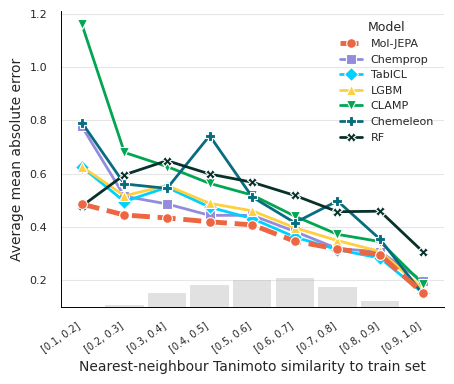

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from colors import DISCRETE_COLORS_ORIG

preds = pd.concat([moljepa_preds, baseline_preds, clamp_preds], ignore_index=True).copy()
preds["model"] = preds["model"].replace(name_map)
preds["y_true"] = pd.to_numeric(preds["y_true"], errors="coerce")
preds["y_pred"] = pd.to_numeric(preds["y_pred"], errors="coerce")
preds["max_sim"] = pd.to_numeric(preds["max_sim"], errors="coerce")
preds = preds.dropna(subset=["y_true", "y_pred", "max_sim"])
preds = preds[preds["max_sim"].between(0, 1)].copy()
preds["abs_error"] = (preds["y_true"] - preds["y_pred"]).abs()

# Raw mean absolute error in fixed Tanimoto-similarity bins.
bin_edges = np.linspace(0, 1, 11)
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_labels = [f"[{left:.1f}, {right:.1f}]" for left, right in zip(bin_edges[:-1], bin_edges[1:])]
preds["sim_bin"] = pd.cut(
    preds["max_sim"], bins=bin_edges, labels=False, include_lowest=True
)

binned_mae = (
    preds.dropna(subset=["sim_bin"])
    .groupby(["model", "sim_bin"], observed=True)
    .agg(mean_mae=("abs_error", "mean"), count=("abs_error", "size"))
    .reset_index()
)
binned_mae["mid"] = binned_mae["sim_bin"].astype(int).map(dict(enumerate(bin_mids)))

# Put stronger models first in the legend and keep their styles fixed across bins.
model_order = (
    preds.groupby("model")["abs_error"].mean().sort_values().index.tolist()
)
palette = {
    model: DISCRETE_COLORS_ORIG[i % len(DISCRETE_COLORS_ORIG)]
    for i, model in enumerate(model_order)
}
markers = ["o", "s", "D", "^", "v", "P", "X", "<", ">"]

# Count each test molecule once rather than once per model.
hist_data = preds.drop_duplicates(["dataset", "split", "smiles"])
hist_counts, _ = np.histogram(hist_data["max_sim"], bins=bin_edges)

# Trim empty similarity bins from the left side of the plot.
first_bin = int(preds["sim_bin"].dropna().min())
visible = np.arange(len(bin_mids)) >= first_bin

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(4.7, 4))

for i, model in enumerate(model_order):
    model_data = binned_mae[binned_mae["model"] == model].sort_values("mid")
    ax.plot(
        model_data["mid"],
        model_data["mean_mae"],
        color=palette[model],
        linestyle="--" if model == "Mol-JEPA" else "-",
        marker=markers[i % len(markers)],
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=3.5 if model == "Mol-JEPA" else 2,
        zorder=5 if model == "Mol-JEPA" else 2,
        label=model,
    )

# Scale the sample-count histogram into the bottom 10% of the MAE axis.
y_min, y_max = ax.get_ylim()
hist_height = 0.10 * (y_max - y_min)
scaled_counts = hist_counts / max(hist_counts.max(), 1) * hist_height
ax.bar(
    bin_mids,
    scaled_counts,
    bottom=y_min,
    width=np.diff(bin_edges) * 0.9,
    color="#bdbdbd",
    alpha=0.45,
    linewidth=0,
    zorder=1,
)
ax.set_ylim(y_min, y_max)

ax.set_ylabel("Average mean absolute error", fontsize=10)
ax.set_xlabel("Nearest-neighbour Tanimoto similarity to train set", fontsize=10)
ax.set_xlim(bin_edges[first_bin], bin_edges[-1])
ax.set_xticks(bin_mids[visible])
ax.set_xticklabels(
    np.asarray(bin_labels)[visible], rotation=35, ha="right", fontsize=7
)
ax.tick_params(axis="y", labelsize=8)
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(title="Model", frameon=False, fontsize=8, title_fontsize=9, ncol=1)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(0.7)
ax.spines["bottom"].set_linewidth(0.7)

plt.tight_layout()
plt.savefig("figures/ood_similarity_vs_error_raw.png", dpi=300, bbox_inches="tight")
plt.show()